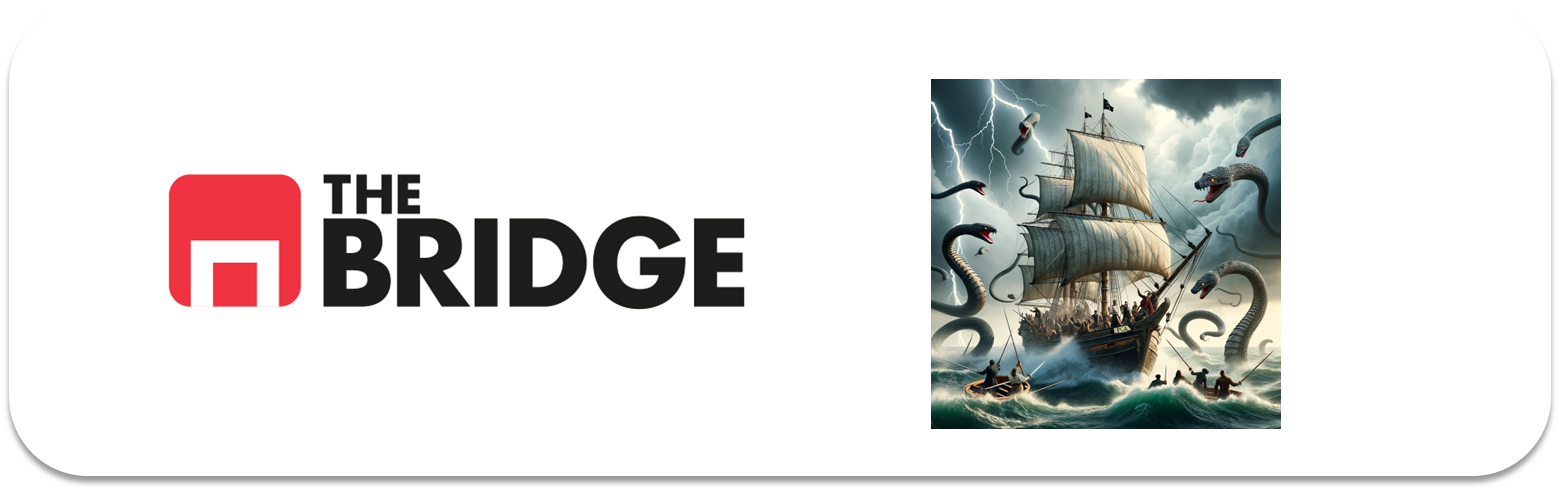

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.decomposition import PCA

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [3]:
#Descargamos el dataset
olivetti = fetch_olivetti_faces(shuffle=False, random_state=42)
X_raw = olivetti.data
y = olivetti.target

#Construir el DataFrame de características
pixel_names = [idx for idx in range(X_raw.shape[1])]
df_pixels = pd.DataFrame(X_raw, columns=pixel_names)

df_pixels['target'] = y

print(f"Dimensiones del dataset: {df_pixels.shape}")

Dimensiones del dataset: (400, 4097)


In [4]:
X = df_pixels.drop(columns=['target'])
y = df_pixels['target']

#Hacemos el split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print(f"Instancias en Train: {X_train.shape[0]}")
print(f"Instancias en Test: {X_test.shape[0]}")

Instancias en Train: 320
Instancias en Test: 80


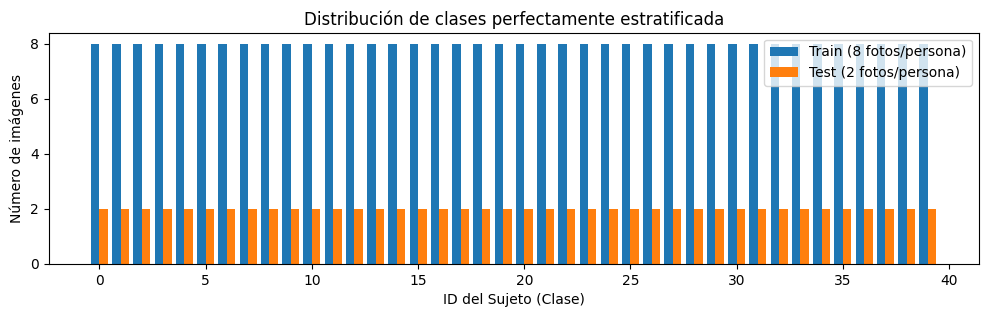

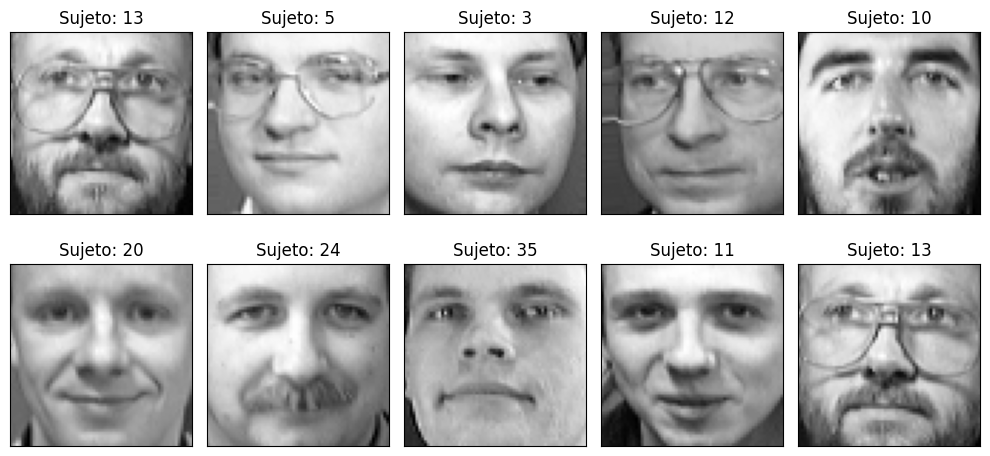

In [6]:
#Verificación del balanceo de clases en Train y Test
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

plt.figure(figsize=(12, 3))
plt.bar(train_counts.index - 0.2, train_counts.values, width=0.4, label='Train (8 fotos/persona)')
plt.bar(test_counts.index + 0.2, test_counts.values, width=0.4, label='Test (2 fotos/persona)')
plt.title("Distribución de clases perfectamente estratificada")
plt.xlabel("ID del Sujeto (Clase)")
plt.ylabel("Número de imágenes")
plt.legend()
plt.show()

# Visualización
fig, axes = plt.subplots(2, 5, figsize=(10, 5), subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train.iloc[i].values.reshape(64, 64), cmap='gray')
    ax.set_title(f"Sujeto: {y_train.iloc[i]}")
plt.tight_layout()
plt.show()

In [7]:
#Modelo baseline
#Usamos un kernel lineal como aproximación
baseline_model = SVC(kernel='linear', random_state=42)

#Validación Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='balanced_accuracy')

mean_cv_recall = cv_scores.mean()
print(f"Recall Medio (Balanced Accuracy) en CV (5-folds): {mean_cv_recall:.4f}")

#Entrenamiento final con todo el Train y evaluación en Test
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

test_recall = balanced_accuracy_score(y_test, y_pred)
print(f"Recall Medio (Balanced Accuracy) en TEST: {test_recall:.4f}")

#Guardamos las métricas en variables
baseline_results = {
    "cv_balanced_accuracy": mean_cv_recall,
    "test_balanced_accuracy": test_recall
}

Recall Medio (Balanced Accuracy) en CV (5-folds): 0.9650
Recall Medio (Balanced Accuracy) en TEST: 0.9750


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [9]:
from sklearn.decomposition import PCA

#Instanciamos PCA sobre el Train
pca_global = PCA(random_state=42)
pca_global.fit(X_train)

# Escoger 5 valores
componentes_propuestos = [8, 24, 48, 72, 102]

In [10]:
resultados_pca = []

# Recuperamos los scores del modelo base guardados en el paso anterior
cv_base = baseline_results["cv_balanced_accuracy"]
test_base = baseline_results["test_balanced_accuracy"]

for n_comp in componentes_propuestos:
    #Aplicamos PCA con el número de componentes actual
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    #Instanciamos el mismo tipo de modelo (SVM Lineal)
    model_pca = SVC(kernel='linear', random_state=42)
    
    #Validación Cruzada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=cv, scoring='balanced_accuracy')
    cv_score_mean = cv_scores.mean()
    
    #Predicción y Score sobre el conjunto de Test
    model_pca.fit(X_train_pca, y_train)
    y_pred_pca = model_pca.predict(X_test_pca)
    test_score = balanced_accuracy_score(y_test, y_pred_pca)
    
    #Calculamos el % de compresión real
    pct_compresion = (n_comp / 4096) * 100
    
    # Calcular diferencias con el modelo base
    dif_cv = cv_score_mean - cv_base
    dif_test = test_score - test_base
    
    #Guardamos
    resultados_pca.append({
        "Nº Componentes": n_comp,
        "% Compresión": f"{pct_compresion:.2f}%",
        "Score CV (Recall)": cv_score_mean,
        "Score Test (Recall)": test_score,
        "Dif CV vs Base": dif_cv,
        "Dif Test vs Base": dif_test
    })
df_resultados = pd.DataFrame(resultados_pca)
print(df_resultados.to_string(index=False))

 Nº Componentes % Compresión  Score CV (Recall)  Score Test (Recall)  Dif CV vs Base  Dif Test vs Base
              8        0.20%             0.8150                0.825         -0.1500            -0.150
             24        0.59%             0.9600                0.950         -0.0050            -0.025
             48        1.17%             0.9600                0.975         -0.0050             0.000
             72        1.76%             0.9625                0.975         -0.0025             0.000
            102        2.49%             0.9650                0.975          0.0000             0.000


In [12]:
#Filtramos por la condición más estricta: pérdida < 3 puntos porcentuales
condicion_3pct = (df_resultados["Dif CV vs Base"] >= -0.03) & (df_resultados["Dif Test vs Base"] >= -0.03)
df_filtrado = df_resultados[condicion_3pct]

umbral_elegido = "3%"

#Si no hay ninguno, relajamos la condición a pérdida < 5 puntos porcentuales
if df_filtrado.empty:
    condicion_5pct = (df_resultados["Dif CV vs Base"] >= -0.05) & (df_resultados["Dif Test vs Base"] >= -0.05)
    df_filtrado = df_resultados[condicion_5pct]
    umbral_elegido = "5%"

if not df_filtrado.empty:
    #El que tiene mayor compresión es el que tiene menos componentes principales
    mejor_opcion = df_filtrado.sort_values(by="Nº Componentes").iloc[0]
    
    print("\n" + "="*50)
    print(f"RECOMENDACIÓN: {umbral_elegido})")
    print("="*50)
    print(f"Número ideal de Componentes Principales es: {mejor_opcion['Nº Componentes']}")
    print(f"Consigue reducir la imagen a un: {mejor_opcion['% Compresión']} del original.")
    print(f"Rendimiento estimado en CV: {mejor_opcion['Score CV (Recall)']:.4f} (Dif: {mejor_opcion['Dif CV vs Base']:.4f})")
    print(f"Rendimiento estimado en Test: {mejor_opcion['Score Test (Recall)']:.4f} (Dif: {mejor_opcion['Dif Test vs Base']:.4f})")



RECOMENDACIÓN: 3%)
Número ideal de Componentes Principales es: 24
Consigue reducir la imagen a un: 0.59% del original.
Rendimiento estimado en CV: 0.9600 (Dif: -0.0050)
Rendimiento estimado en Test: 0.9500 (Dif: -0.0250)


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [13]:
#Rango solicitado: entre el 0.1% (1 por mil) y el 1.0% (1 por ciento)
componentes_extrema_compresion = [4, 10, 20, 30, 41]

resultados_descompresion = []

#Recuperamos los baselines originales
cv_base = baseline_results["cv_balanced_accuracy"]
test_base = baseline_results["test_balanced_accuracy"]

for n_comp in componentes_extrema_compresion:
    #Instanciamos y ajustamos PCA con el número de componentes actual
    pca = PCA(n_components=n_comp, random_state=42)
    pca.fit(X_train)
    
    #Simular el proceso: Comprimir, enviar y descomprimir en servidor
    X_train_compressed = pca.transform(X_train)
    X_train_unzipped = pca.inverse_transform(X_train_compressed)
    
    X_test_compressed = pca.transform(X_test)
    X_test_unzipped = pca.inverse_transform(X_test_compressed)
    
    #Evaluar el modelo en el servidor 
    model_servidor = SVC(kernel='linear', random_state=42)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_servidor, X_train_unzipped, y_train, cv=cv, scoring='balanced_accuracy')
    cv_score_mean = cv_scores.mean()
    
    #Ajuste final y test
    model_servidor.fit(X_train_unzipped, y_train)
    y_pred_unzipped = model_servidor.predict(X_test_unzipped)
    test_score = balanced_accuracy_score(y_test, y_pred_unzipped)
    
    #Factores de compresión y métricas de negocio
    pct_compresion = (n_comp / 4096) * 100
    dif_cv = cv_score_mean - cv_base
    dif_test = test_score - test_base
    
    resultados_descompresion.append({
        "Nº Componentes (PCA)": n_comp,
        "% Compresión": f"{pct_compresion:.3f}%",
        "Score CV (Reconstruido)": cv_score_mean,
        "Score Test (Reconstruido)": test_score,
        "Dif CV vs Base": dif_cv,
        "Dif Test vs Base": dif_test
    })

#DataFrame Comparativo
df_resultados_central = pd.DataFrame(resultados_descompresion)
print(df_resultados_central.to_string(index=False))

 Nº Componentes (PCA) % Compresión  Score CV (Reconstruido)  Score Test (Reconstruido)  Dif CV vs Base  Dif Test vs Base
                    4       0.098%                   0.6025                     0.5250         -0.3625           -0.4500
                   10       0.244%                   0.8750                     0.9000         -0.0900           -0.0750
                   20       0.488%                   0.9550                     0.9375         -0.0100           -0.0375
                   30       0.732%                   0.9600                     0.9625         -0.0050           -0.0125
                   41       1.001%                   0.9600                     0.9625         -0.0050           -0.0125


## VISUALIZACIÓN OPCIONAL

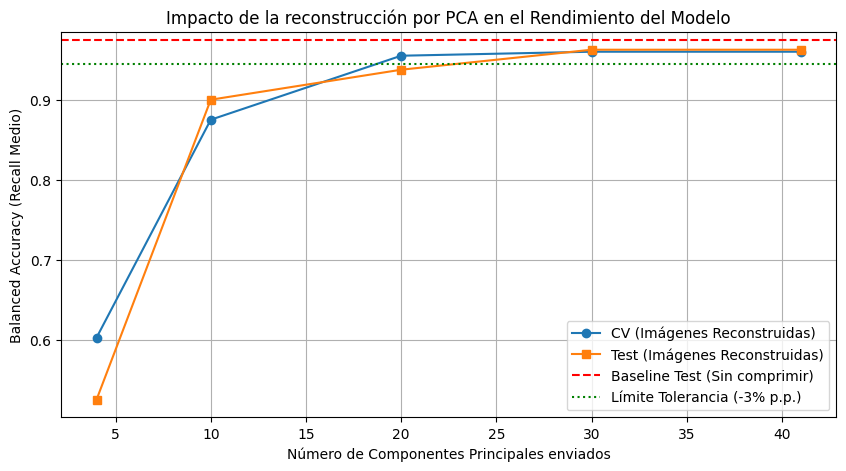

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(df_resultados_central["Nº Componentes (PCA)"], df_resultados_central["Score CV (Reconstruido)"], marker='o', label='CV (Imágenes Reconstruidas)')
plt.plot(df_resultados_central["Nº Componentes (PCA)"], df_resultados_central["Score Test (Reconstruido)"], marker='s', label='Test (Imágenes Reconstruidas)')
plt.axhline(y=test_base, color='r', linestyle='--', label='Baseline Test (Sin comprimir)')
plt.axhline(y=test_base - 0.03, color='g', linestyle=':', label='Límite Tolerancia (-3% p.p.)')

plt.title("Impacto de la reconstrucción por PCA en el Rendimiento del Modelo")
plt.xlabel("Número de Componentes Principales enviados")
plt.ylabel("Balanced Accuracy (Recall Medio)")
plt.legend()
plt.grid(True)
plt.show()

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

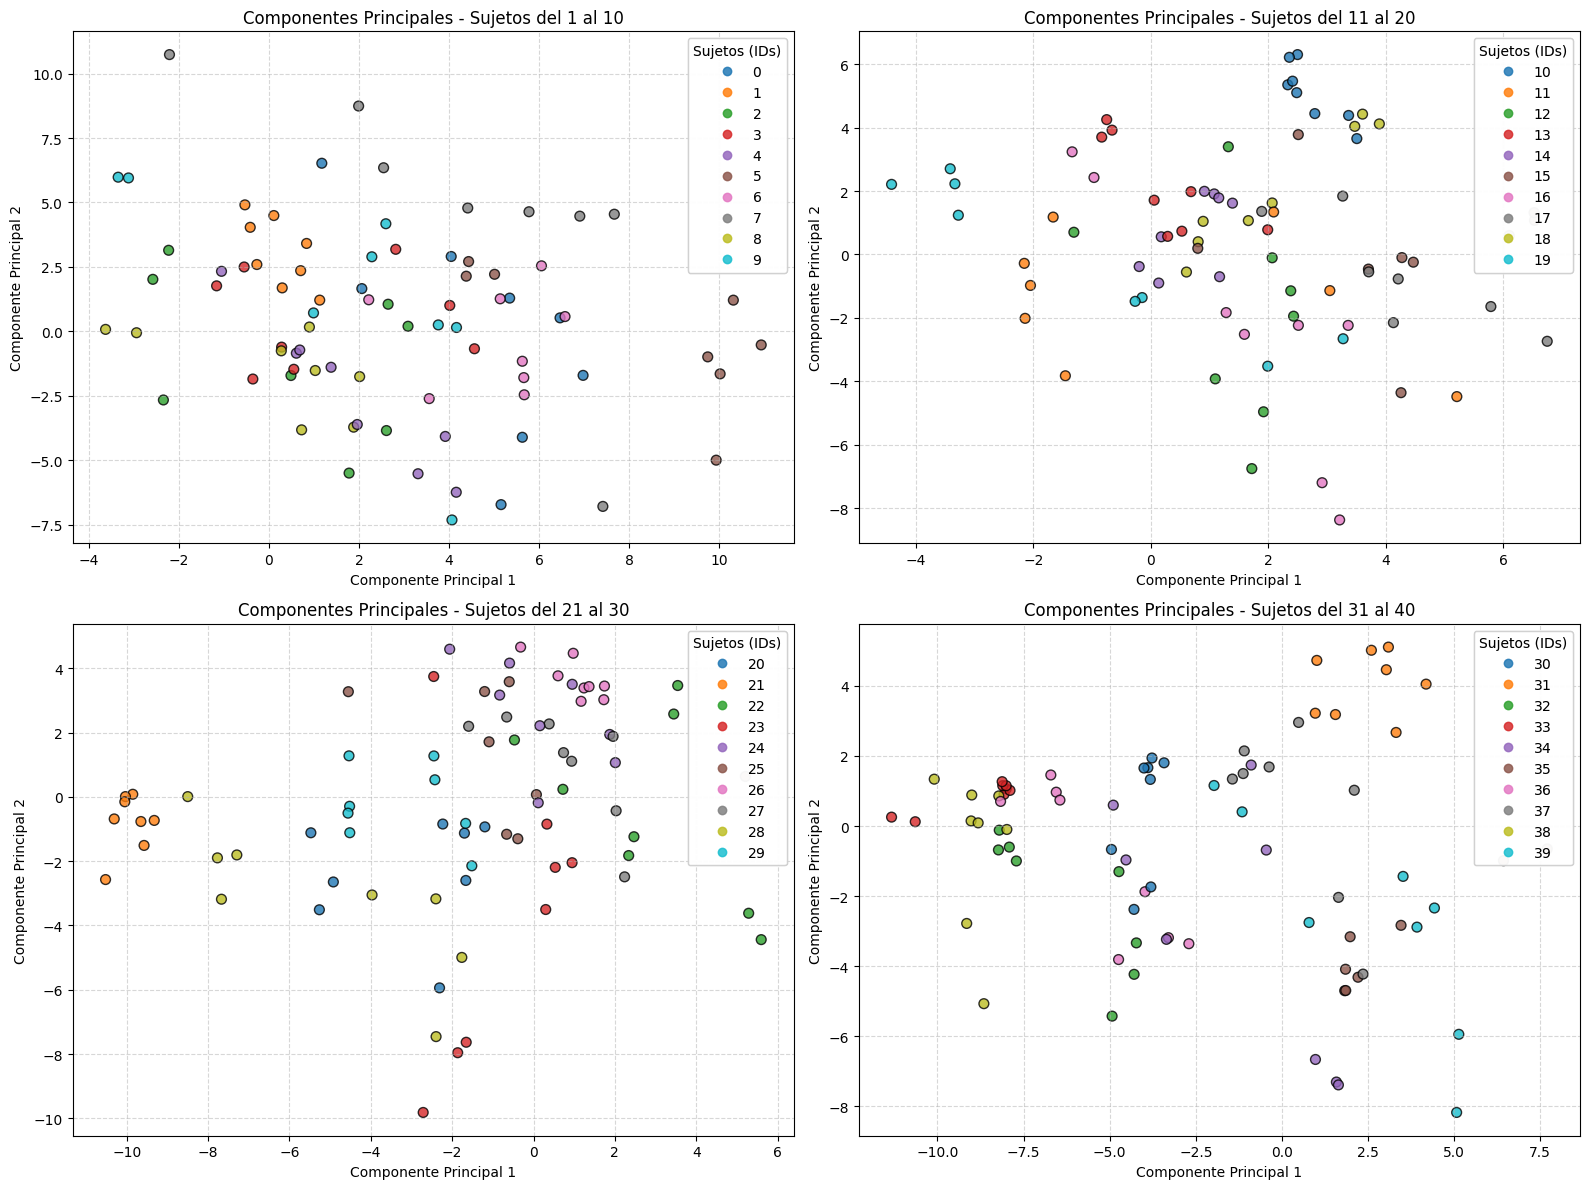

In [5]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

#Creamos un DataFrame temporal para facilitar el filtrado por clases
df_plot = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'])
df_plot['target'] = y_train.values

#Configuramos los subgráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel() # Aplanamos la matriz de ejes para iterar fácilmente

#Rangos de clases para cada gráfico: (1-10), (11-20), (21-30), (31-40)
rangos_clases = [(0, 9), (10, 19), (20, 29), (30, 39)]

for idx, (inicio, fin) in enumerate(rangos_clases):
    ax = axes[idx]
    df_filtrado = df_plot[(df_plot['target'] >= inicio) & (df_plot['target'] <= fin)]
    
    #Dibujamos el scatter plot
    scatter = ax.scatter(
        df_filtrado['PC1'], 
        df_filtrado['PC2'], 
        c=df_filtrado['target'], 
        cmap='tab10',
        s=50, 
        edgecolors='k', 
        alpha=0.8
    )
    
    legend = ax.legend(*scatter.legend_elements(), title="Sujetos (IDs)", loc="upper right")
    ax.add_artist(legend)
    
    ax.set_title(f"Componentes Principales - Sujetos del {inicio+1} al {fin+1}")
    ax.set_xlabel("Componente Principal 1")
    ax.set_ylabel("Componente Principal 2")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Comparativa de calidad de imagen según la compresión de red:


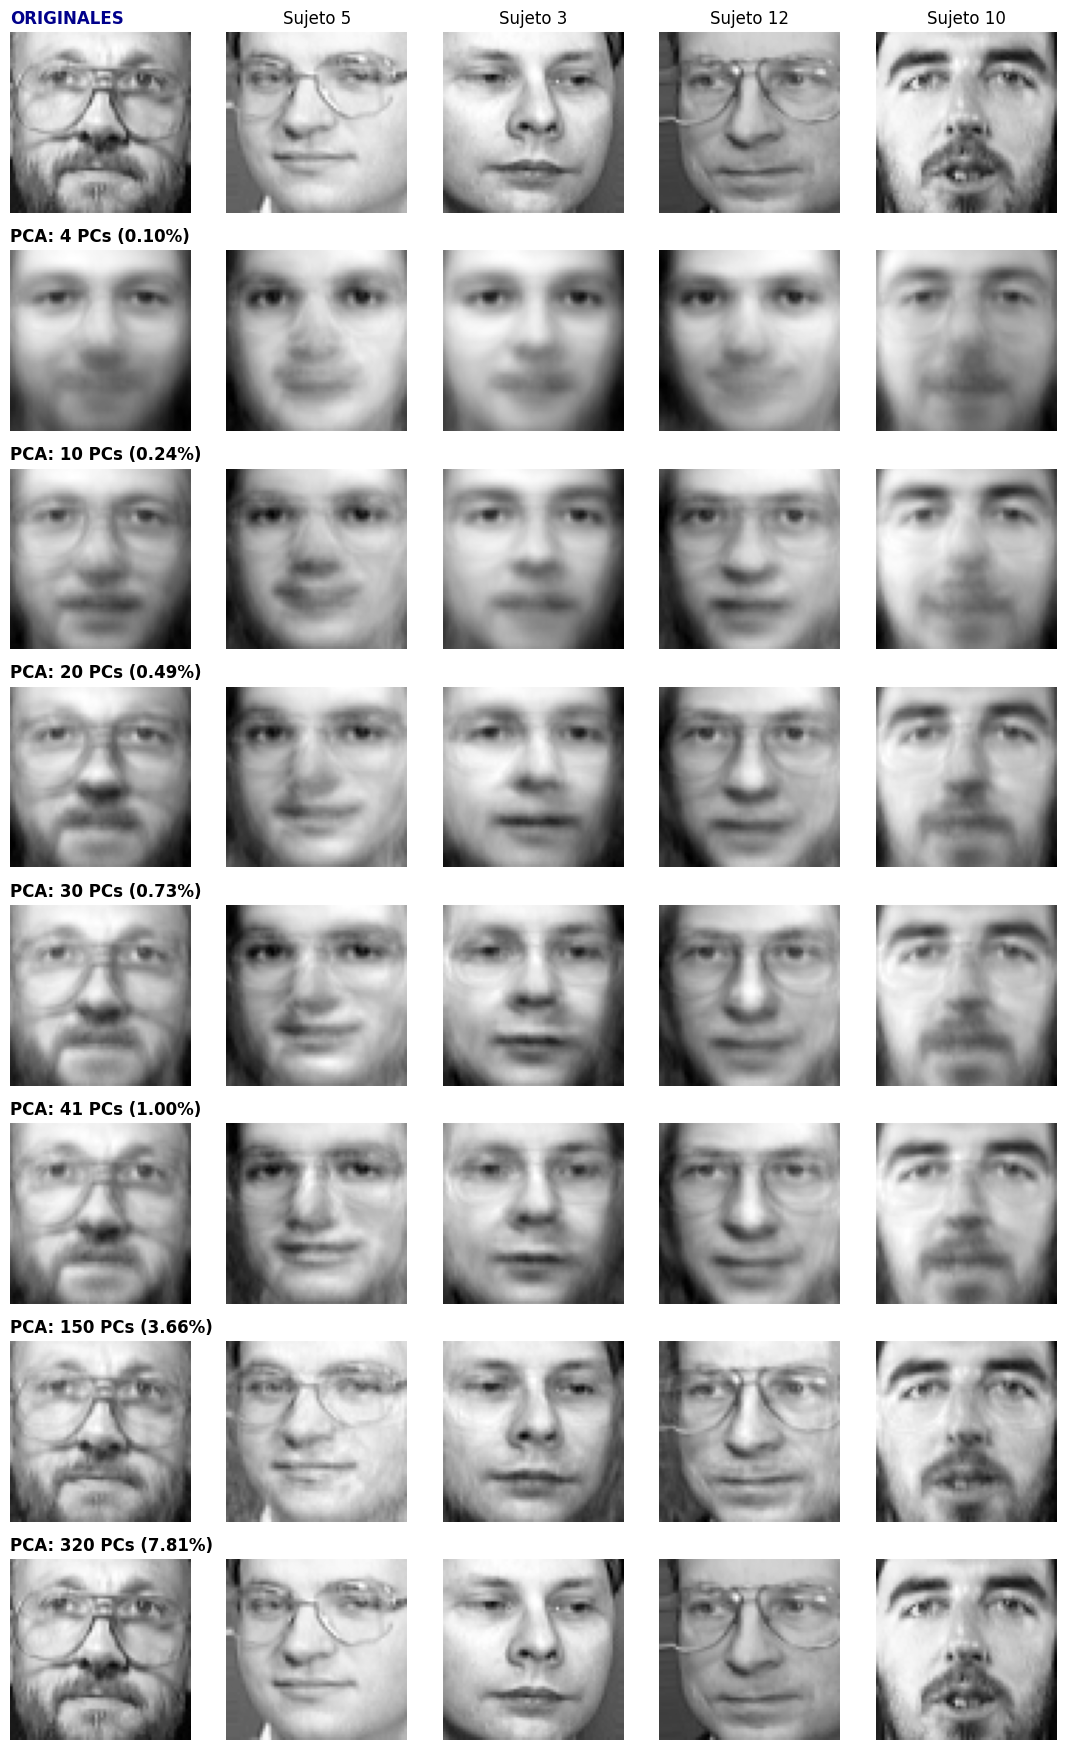

In [6]:
def comparar_reconstruccion_caras(X_original, y_original, lista_pcs, num_caras_a_mostrar=5):
    """
    Visualiza una fila con las caras originales y filas subsecuentes con la reconstrucción 
    de esas mismas caras para diferentes números de Componentes Principales.
    """
    caras_originales = X_original.iloc[:num_caras_a_mostrar].values
    ids_sujetos = y_original.iloc[:num_caras_a_mostrar].values
    
    total_filas = 1 + len(lista_pcs)
    
    fig, axes = plt.subplots(total_filas, num_caras_a_mostrar, figsize=(num_caras_a_mostrar * 2.2, total_filas * 2.2))
    
    #Fila 1: caras originales
    for j in range(num_caras_a_mostrar):
        ax = axes[0, j]
        ax.imshow(caras_originales[j].reshape(64, 64), cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_title("ORIGINALES", loc='left', fontweight='bold', color='darkblue')
        else:
            ax.set_title(f"Sujeto {ids_sujetos[j]}")
            
    #Filas siguientes: caras reconstruidas para cada valor de PCA
    for i, n_comp in enumerate(lista_pcs):
        #Ajustamos PCA y reconstruimos
        pca_temp = PCA(n_components=n_comp, random_state=42)
        X_train_compressed = pca_temp.fit_transform(X_original)
        X_reconstruido = pca_temp.inverse_transform(X_train_compressed)
        
        for j in range(num_caras_a_mostrar):
            ax = axes[i + 1, j]
            ax.imshow(X_reconstruido[j].reshape(64, 64), cmap='gray')
            ax.axis('off')
            if j == 0:
                #El factor de compresión real respecto a 4096 píxeles
                pct = (n_comp / 4096) * 100
                ax.set_title(f"PCA: {n_comp} PCs ({pct:.2f}%)", loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()


#Añadimos los casos solicitados de 150 y 320 componentes a la lista previa
todos_los_componentes = [4, 10, 20, 30, 41, 150, 320]

print("Comparativa de calidad de imagen según la compresión de red:")
comparar_reconstruccion_caras(
    X_original=X_train, 
    y_original=y_train, 
    lista_pcs=todos_los_componentes, 
    num_caras_a_mostrar=5
)